In [49]:
import polars as pl
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
pl.enable_string_cache()


In [51]:
df = pl.read_csv('03.BaseDPEvolucaoMensalCisp.csv', separator=';', encoding='iso-8859-1')
df_dp = pl.read_csv('08.DP.csv', separator=',')
df = df.join(df_dp, left_on='cisp', right_on='codDP', how='left')

df.glimpse()

Rows: 34848
Columns: 65
$ cisp                       <i64> 1, 4, 5, 6, 7, 9, 10, 12, 13, 14
$ mes                        <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ ano                        <i64> 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003, 2003
$ mes_ano                    <str> '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01', '2003m01'
$ aisp                       <i64> 5, 5, 5, 1, 1, 2, 2, 19, 19, 23
$ risp                       <i64> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
$ munic                      <str> 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro', 'Rio de Janeiro'
$ mcirc                      <i64> 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557, 3304557
$ regiao                     <str> 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Capital', 'Ca

In [52]:
df = df.with_columns(pl.col('munic').cast(pl.Categorical), pl.col('regiao').cast(pl.Categorical), pl.col('nome').cast(pl.Categorical))

In [53]:
coluna1 = 'roubo_veiculo'
coluna2 = 'recuperacao_veiculos'

corr = df.select(pl.corr(coluna1, coluna2)).item()

print(corr)

0.8454989636146697


In [54]:
df_municipio_agg = (df.group_by('munic').agg([pl.mean(coluna1).alias(f'media_{coluna1}'), pl.mean(coluna2).alias(f'media_{coluna2}')]))

df_municipio_agg.select(pl.corr(f'media_{coluna1}', f'media_{coluna2}'))



media_roubo_veiculo
f64
0.974349


In [55]:
df_municipio_ano_agg = (df.group_by(['munic', 'ano']).agg([pl.corr(coluna1, coluna2).alias(f'correlacao{coluna1}_{coluna2}')]).sort('ano'))

df_municipio_ano_agg.filter(pl.col('munic') == 'Rio de Janeiro')

munic,ano,correlacaoroubo_veiculo_recuperacao_veiculos
cat,i64,f64
"""Rio de Janeiro""",2003,0.86475
"""Rio de Janeiro""",2004,0.850561
"""Rio de Janeiro""",2005,0.858212
"""Rio de Janeiro""",2006,0.751238
"""Rio de Janeiro""",2007,0.729301
…,…,…
"""Rio de Janeiro""",2020,0.704021
"""Rio de Janeiro""",2021,0.715899
"""Rio de Janeiro""",2022,0.689926


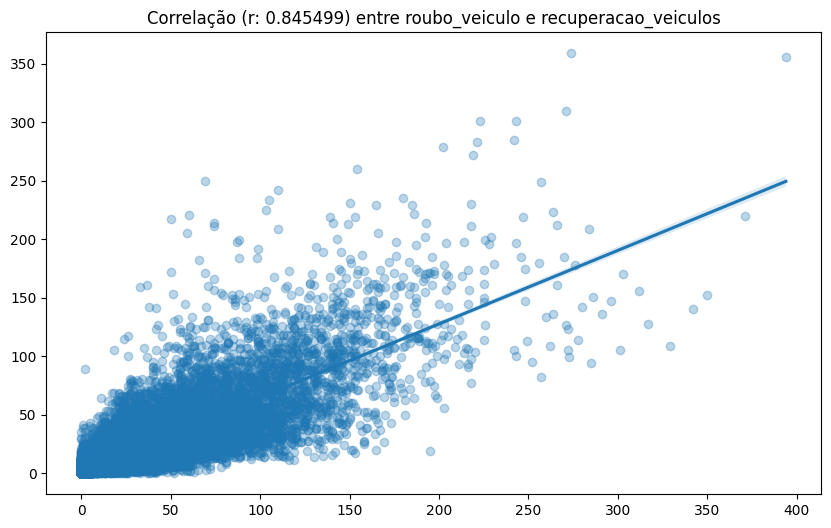

In [56]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x=coluna1, y=coluna2, scatter_kws={'alpha':0.3})
plt.title(f'Correlação (r:{corr: 2f}) entre {coluna1} e {coluna2}')
plt.show()